In [ ]:
import os
import io
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from google.colab import drive

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
matplotlib.use("Agg")  # backend senza GUI

def rasterize_segments(segments, img_size=(515, 389)):
    '''
    Given the coordinates, it creates a binary image of specific dimensions.
    '''
    fig, ax = plt.subplots(figsize=(img_size[0]/100, img_size[1]/100), dpi=100)
    ax.set_axis_off()
    ax.set_aspect('equal', adjustable='box')

    # Calculate global bounding box for all segments to normalize scaling
    all_coords = np.vstack(segments)
    min_x, max_x = all_coords[:, 0].min(), all_coords[:, 0].max()
    min_y, max_y = all_coords[:, 1].min(), all_coords[:, 1].max()

    # Adjust plot limits to fit all segments tightly
    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)

    for seg in segments:
        if len(seg) > 1:
            ax.plot(seg[:,0], seg[:,1], color='black', linewidth=1)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Render the figure to a buffer
    fig.canvas.draw()
    img_rgba = np.array(fig.canvas.renderer.buffer_rgba())
    plt.close(fig)

    # I delete the figure to avoid memory saturation
    del fig, ax
    if np.random.randint(0, 100) == 0:
      gc.collect()

    # Convert RGBA to grayscale
    img = Image.fromarray(img_rgba).convert("L")
    img = img.resize(img_size, Image.LANCZOS)

    # Binarize the image
    img = img.point(lambda p: 255 if p > 128 else 0)

    return np.array(img)

In [ ]:
def Image_Loader(dataframe, range_0, range_length, k):
   '''
   This function gives as output the set of images that will be evaluated and their respective fractal dimension (label) as np arrays
   '''
   eval_set = []
   label = []

   for i in range(range_0,range_length):

      fname = dataframe["Percorso_Coordinate"][i]
      Fdim = dataframe["Dimensione_Frattale"][i]
      coords = np.load(fname)

      threshold = 200

      element = [250, 500, 750, 1000, 1500, 2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000]
      portion = element[k]
      start = np.random.randint(0, 20001-portion)
      end = start + portion
      coordss = coords[start:end]
      img = rasterize_segments([coordss], img_size=(515, 389))

      img1 = np.array(img)
      img2 = (img1 > threshold).astype(np.float32)

      eval_set.append(img2)
      label.append(Fdim)

   eval_set = np.array(eval_set)
   label = np.array(label)

   return eval_set, label

In [ ]:
def boxcount(Z, k):
    '''
    Given the dimension of the box k, and the matrix Z, it returns the number of
    boxes, used to cover the matrix, with at least a 1 inside.
    '''
    rows, cols = Z.shape
    n_rows = math.ceil(rows / k)
    n_cols = math.ceil(cols / k)

    count = 0
    for i in range(n_rows):
        for j in range(n_cols):
            block = Z[
                i*k : min((i+1)*k, rows),
                j*k : min((j+1)*k, cols)
            ]
            if np.any(block):
                count += 1
    return count

def fractal_dimension(image):
    """
    Given an image, it converts it into a binary matrix with values 0 and 1.
    Using this binary representation, it applies the box‑counting method:
    for multiple grid sizes, it counts how many boxes contain part of the curve.

    The fractal dimension is estimated as the slope of the linear regression
    between log(box count) and log(box size).
    """

    img = np.array(image)

    binary = (img == 0).astype(np.uint8)

    sizes = [2, 4, 8, 16, 32, 64]

    counts = [boxcount(binary, k) for k in sizes]

    log_sizes = np.log(sizes)
    log_counts = np.log(counts)

    coeffs = np.polyfit(log_sizes, log_counts, 1)
    fractal_dim = -coeffs[0]

    return fractal_dim

In [ ]:
drive_base = "/content/drive/My Drive/coord"
local_base = "/content/dataset"
os.makedirs(local_base, exist_ok=True)

def upload_modify_csv(path_csv, fil):
    df = pd.read_csv(path_csv)
    df["Percorso_Coordinate"] = df["Percorso_Coordinate"].str.replace(
        f"/content/drive/My Drive/{fil}/",
        f"/content/dataset/{fil}/{fil}/"
    )
    return df

# List of files
folder = [f"DATASET-{i}" for i in range(1,8)]


# Extract the ZIP files locally
for fil in folder:
    zip_path = os.path.join(drive_base, f"{fil}.zip")
    estrai_in = os.path.join(local_base, fil)
    if os.path.exists(zip_path) and not os.path.exists(estrai_in):
        os.makedirs(estrai_in, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(estrai_in)
        print(f"Extract: {fil}.zip")

# Uploading and modifing the original CSV

df_gruops = []
for idx in range(1,8):
    group = [
        f"DATASET-{idx}"
    ]
    df_list = []
    for fil in group:
        path_csv = os.path.join(local_base, fil, fil, "a_etichette.csv")
        if os.path.exists(path_csv):
            df_modificato = upload_modify_csv(path_csv, fil)
            df_list.append(df_modificato)
    if df_list:
     df_group = pd.concat(df_list, ignore_index=True)
     df_gruops.append(df_group)
    else:
     print(f"No CSV found for this group {idx}")

# Putting everything togheter

df = pd.concat(df_gruops, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

# Dividing the dataset in local training + (validation + test) CSV files

train_size = 0.71429
val_size = 0.142855
test_size = 0.142855

train_dff, df_temp = train_test_split(df, test_size=(1 - train_size), random_state=300)

val_dff, test_dff = train_test_split(df_temp, test_size=(test_size / (val_size + test_size)), random_state=300)

train_dff.to_csv("/content/train_df_local.csv", index=False)

val_dff.to_csv("/content/val_df_local.csv", index=False)

test_dff.to_csv("/content/test_df_local.csv", index=False)

#  Final Sets

train_df = pd.read_csv("/content/train_df_local.csv")
val_df = pd.read_csv("/content/val_df_local.csv")
test_df = pd.read_csv("/content/test_df_local.csv")

Mounted at /content/drive
✅ Estratto: DATASET-1.zip
✅ Estratto: DATASET-2.zip
✅ Estratto: DATASET-3.zip
✅ Estratto: DATASET-4.zip
✅ Estratto: DATASET-5.zip
✅ Estratto: DATASET-6.zip
✅ Estratto: DATASET-7.zip
15000 3000 3000


In [ ]:
# Evaluate the images and the Relative Percentage Error

for k in range(13):
  test_images, FDim_label = Image_Loader(test_df, 0, int(len(test_df)), k)
  D = [fractal_dimension_primoo(img) for img in test_images]
  errors = ((np.array(D) - np.array(FDim_label)) / np.array(FDim_label)) * 100

  col_name = f"Error_{k}"
  test_df[col_name] = errors

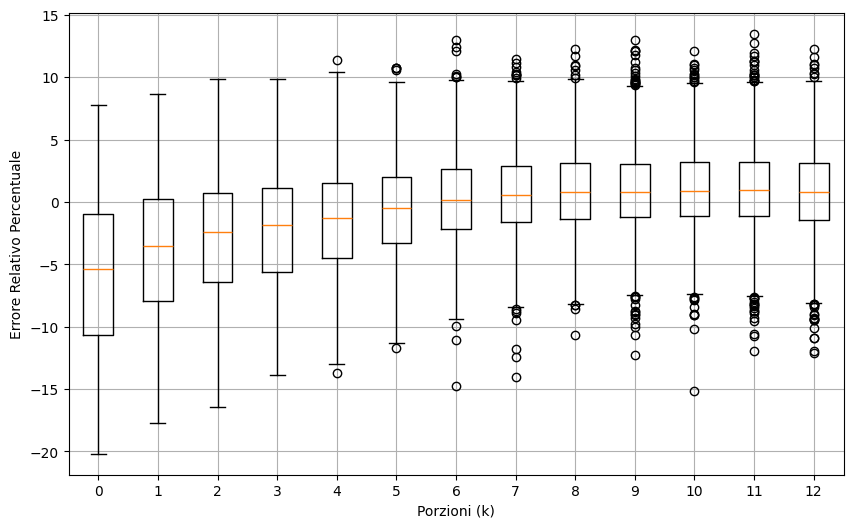

In [ ]:
%matplotlib inline

# Visualization of the errors

cols = [f"Error_{k}" for k in range(13)]

data = [test_df[col].dropna().values for col in cols]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=[str(k) for k in range(13)], showfliers=True)

plt.xlabel("Portion")
plt.ylabel("Relative Percentage Error")
plt.title("Distributions of Errors Given Portion")
plt.grid(True)
plt.show()

In [ ]:
# Upload the results to a drive folder

drive.mount('/content/drive')

result_dir = '/content/drive/MyDrive/Results'
os.makedirs(result_dir, exist_ok=True)

csv_path = os.path.join(result_dir, 'dimensioni_frattali.csv')
test_df.to_csv(csv_path, index_label='Indice')

print(f"CSV path: {csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CSV salvato in: /content/drive/MyDrive/RisultatiBoxPorzioniEsatti/dimensioni_frattali.csv
